## Notebook Summary

This notebook presents implementations of kalman, extended kalman, and unscented kalman filters applied to the motion of a simple pendulum. This system exemplifies how linearization (Kalman) breaks down at large angle arguments, justifying the use of nonlinear extensions of the kalman filter, ekf and ukf.

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

plt.close('all')

In [2]:
# Simulation parameters

# System params
G = 9.81        # gravity accel metric
L = 0.5         # Pendulum length m
T = 5           # total simulation duration
fs = 5000         # sample rate, Hz
theta_0 = np.deg2rad(60.0)   # initial angle: if large, standard kalman breaks down bc small angle approx
theta_dot_0 = 0.0      # initial angular velocity (at rest), rad/s

# Noise params
Q = np.diag([0.001, 0.001])   # process noise covariance, tuning param: very low -> we trust our dynamics model
R = 0.1                     # observation noise variance; if using actual measurements, determined by actual sensor noise


# Helper function - pendulum f0
def get_pendulum_natural_freq(length_m):
    return 1 / (2 * np.pi) * np.sqrt(G / length_m)


# Computed from params
dt = 1 / fs

# Ensure that sampling frequency can resolve natural freq of pendulum
assert get_pendulum_natural_freq(L) < (fs /2), "Increase samplerate"

## Ground truth, observation simulations

In [3]:
# Ground truth simulation

N = int(T / dt)     # total time steps
theta = np.zeros(N)
theta_dot = np.zeros(N)
theta[0] = theta_0      # Define initial angle theta
theta_dot[0] = theta_dot_0    

for n in range(1, N):
    theta_ddot = -(G / L) * np.sin(theta[n - 1])    # true dynamics @ time step n-1
    theta_dot[n] = theta_dot[n - 1] + theta_ddot * dt   # Euler integration
    theta[n] = theta[n - 1] + theta_dot[n - 1] * dt

# Add gaussian noise to theta to generate "observations"
z = theta + np.sqrt(R) * np.random.randn(N)

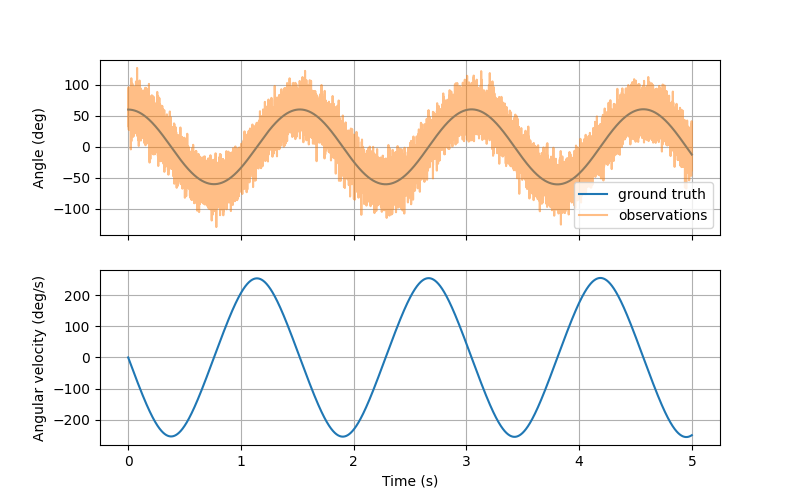

In [4]:
# Plot ground truth

plt.close('all')
t = np.arange(N) * dt

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t, np.rad2deg(theta), label='ground truth')
axes[0].plot(t, np.rad2deg(z), label='observations', alpha=0.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, np.rad2deg(theta_dot))
axes[1].set_ylabel('Angular velocity (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True)
plt.show()

### Re: Euler integration to compute ground truth

Integration with low fs eventually diverges to to energy accumulation. Samplerate increased here, which produces effectively constant amplitude over relatively small T

If longer T or low fs required, use scipy.integrate.solve_ivp with RK45

## Initial Conditions for filtering (same across all 3 methods)

In [5]:
# Initial conditions — common to all three filters

x0 = np.array([z[0], 0.0])    # initial state: first observation, at rest
# P0 = np.diag([R, 0.01])       # angle uncertainty matches sensor, velocity uncertainty small
P0 = np.diag([10., 10.])       # init high uncertainty
I = np.eye(2)

## Standard Kalman Filter

In [6]:
# Apply Standard Kalman Filter

# State transition matrix: constant
F = np.array([[1, dt], [-G * dt / L, 1]])

# Observation matrix
H = np.array([1., 0.])     # Observation matrix, need [1 x 2] dims

# Init and preallocate
x = x0.copy()
P = P0.copy()
x_kf = np.zeros((N, 2))       # x predicted

for n in range(N):
    # Predict
    x = F @ x              # Curr state prior
    P = F @ P @ F.T + Q    # Uncertainty prior

    # Update
    S = H @ P @ H.T + R   # Innovation covar
    K = P @ H.T / S       # Kalman gain
    v = z[n] - H @ x      # Innovation
    x += K * v            # Curr state posterior
    P = (I - np.outer(K, H)) @ P # Uncertainty posterior

    # Update estimate
    x_kf[n] = x

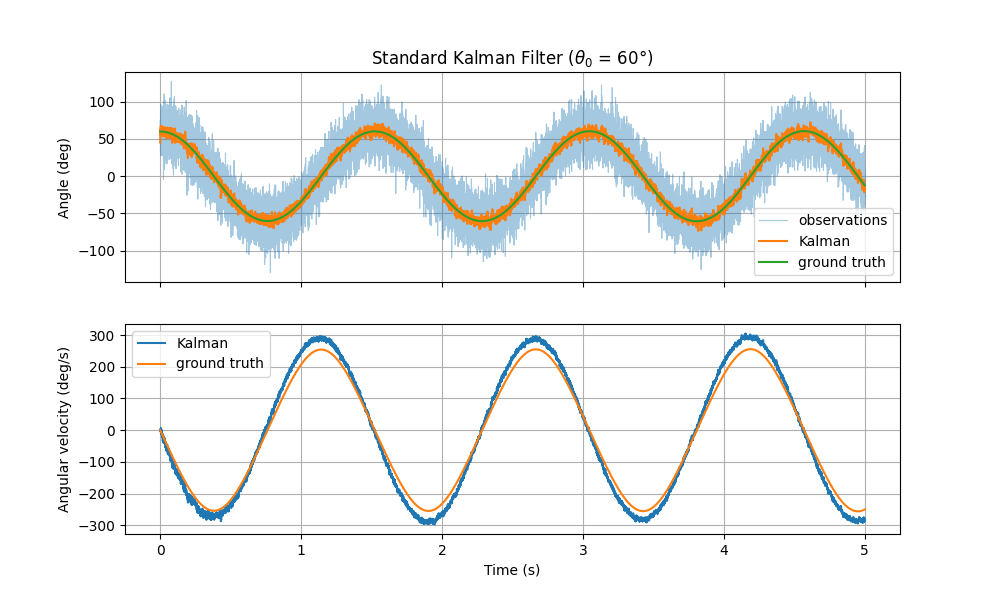

In [7]:
# Plot Kalman result

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, np.rad2deg(z), label='observations', alpha=0.4, lw=0.8)
axes[0].plot(t, np.rad2deg(x_kf[:, 0]), label='Kalman', lw=1.5)
axes[0].plot(t, np.rad2deg(theta), label='ground truth', lw=1.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title(f'Standard Kalman Filter ($\\theta_0$ = {np.rad2deg(theta_0):.0f}°)')

axes[1].plot(t, np.rad2deg(x_kf[:, 1]), label='Kalman', lw=1.5)
axes[1].plot(t, np.rad2deg(theta_dot), label='ground truth', lw=1.5)
axes[1].set_ylabel('Angular velocity (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [8]:
# Helper function for computing RMSE
def compute_rmse(true_vals, estimated_vals):
    return np.sqrt(np.mean((true_vals - estimated_vals) ** 2))

In [9]:
# Compute RMSE Standard Kalman

# Angle theta
rmse_kf_theta = compute_rmse(theta, x_kf[:, 0])

# Angular velocity theta_dot
rmse_kf_theta_dot = compute_rmse(theta_dot, x_kf[:, 1])

print(f"Init angle: {np.round(np.rad2deg(theta_0))}")
print(f"    KF angle RMSE: {np.rad2deg(rmse_kf_theta):.4f} deg")
print(f"    KF velocity RMSE: {np.rad2deg(rmse_kf_theta_dot):.4f} deg/s")

Init angle: 60.0
    KF angle RMSE: 4.0677 deg
    KF velocity RMSE: 26.6158 deg/s


### Standard Kalman Filter Results

| $\theta_0$ (deg) | Angle RMSE (deg) | Velocity RMSE (deg/s) |
|---|---|---|
| 15 | 4.02 | 5.71 |
| 30 | 4.03 | 6.38 |
| 45 | 4.00 | 13.76 |
| 60 | 4.06 | 27.43 |

Angle RMSE is stable across all initial angles — velocity RMSE grows significantly with angle.

- theta estimates are constrained, as theta is an observed value and kalman gain can override model error
- since theta_dot is not directly observed, its estimate degrades as initial angle increases and the linearized dynamics model breaks down

## Extended Kalman Filter

In [10]:
# EKF Implementation

# Differs from standard KF in that:
#    - true nonlinear state transition f() used in predict step
#    - covar prediction P uses Jacobian F(n) (F now computed every time step using current theta estimate)


# Init and preallocate
x = x0.copy()
P = P0.copy()
x_ekf = np.zeros((N, 2))       # x predicted

for n in range(N):
    # Predict: nonlinear state transition
    x = np.array([
        x[0] + x[1] * dt,
        x[1] - (G / L) * np.sin(x[0]) * dt
        ])  # Curr state prior

    # Covariance, Jacobian evaluated at current estimate
    F_n = np.array([[1., dt],
                   [-(G / L) * np.cos(x[0]) * dt, 1.]])

    # Predict covariance
    P = F_n @ P @ F_n.T + Q    # Uncertainty prior

    # Update
    S = H @ P @ H.T + R   # Innovation covar
    K = P @ H.T / S       # Kalman gain
    v = z[n] - H @ x      # Innovation
    x += K * v            # Curr state posterior
    P = (I - np.outer(K, H)) @ P # Uncertainty posterior

    # Update estimate
    x_ekf[n] = x

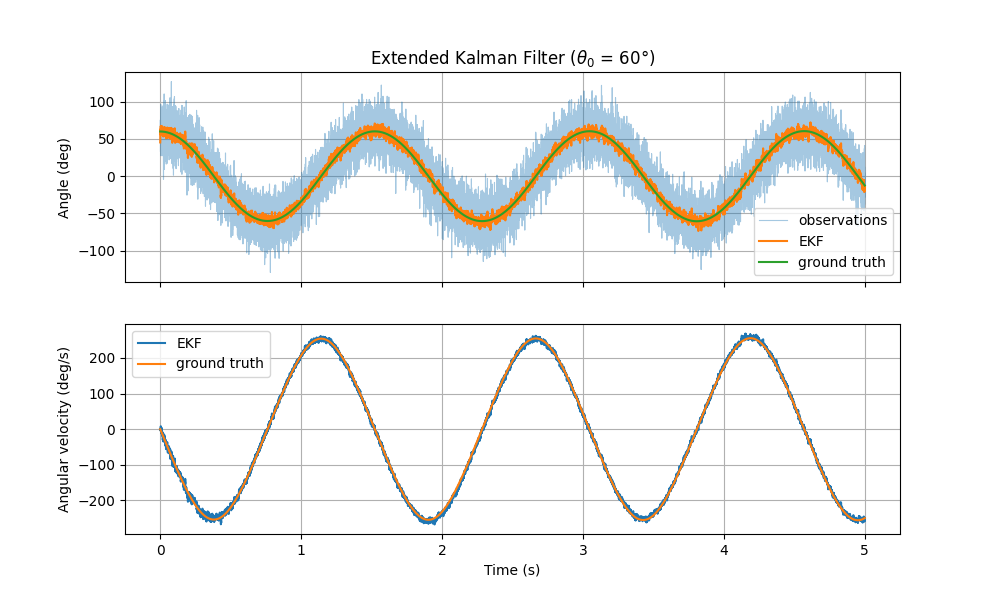

In [11]:
# Plot EKF result

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, np.rad2deg(z), label='observations', alpha=0.4, lw=0.8)
axes[0].plot(t, np.rad2deg(x_ekf[:, 0]), label='EKF', lw=1.5)
axes[0].plot(t, np.rad2deg(theta), label='ground truth', lw=1.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title(f'Extended Kalman Filter ($\\theta_0$ = {np.rad2deg(theta_0):.0f}°)')

axes[1].plot(t, np.rad2deg(x_ekf[:, 1]), label='EKF', lw=1.5)
axes[1].plot(t, np.rad2deg(theta_dot), label='ground truth', lw=1.5)
axes[1].set_ylabel('Angular velocity (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [12]:
# Compute RMSE Extended Kalman

# Angle theta
rmse_ekf_theta = compute_rmse(theta, x_ekf[:, 0])

# Angular velocity theta_dot
rmse_ekf_theta_dot = compute_rmse(theta_dot, x_ekf[:, 1])

print(f"Init angle: {np.round(np.rad2deg(theta_0))}")
print(f"    EKF angle RMSE: {np.rad2deg(rmse_ekf_theta):.4f} deg")
print(f"    EKF velocity RMSE: {np.rad2deg(rmse_ekf_theta_dot):.4f} deg/s")

Init angle: 60.0
    EKF angle RMSE: 4.0682 deg
    EKF velocity RMSE: 4.9867 deg/s


### EKF Results

| $\theta_0$ (deg) | Angle RMSE (deg) | Velocity RMSE (deg/s) |
|---|---|---|
| 15 | 4.04 | 6.61 |
| 30 | 4.06 | 6.24 |
| 45 | 4.04 | 4.93 |
| 60 | 4.09 | 5.17 |

- KF and EKF perform similarly at small angles (expected - small angle approx is valid)
- EKF velocity RMSE stable at large angles while KF grows
- Same effect as with Standard Kalman produces similar angle RMSE behavior in EKF

## Unscented Kalman Filter

In [13]:
# UKF Implementation

# No Jacobian computation
# No linearization, sigma points pushed through nonlinear f()
# Mean and Covariance predictions reconstructed from transformed sigma points

n_state = 2           # state dim
kappa = 3 - n_state   # sigma spread param

# Init and preallocate
x = x0.copy()
P = P0.copy()
x_ukf = np.zeros((N, 2))       # x predicted
sigma = np.zeros((2 * n_state + 1, 2))            
sigma_pred = np.zeros((2 * n_state + 1, 2)) 

# Sigma point weights
W_m = np.array([kappa / (n_state + kappa)] + [1. / (2 * (n_state + kappa))] * 2 * n_state)
W_c = W_m.copy()

for n in range(N):
    # Sigma points
    S_chol = np.linalg.cholesky((n_state + kappa) * P)  # [2 x 2] matrix sqrt
    sigma[0] = x                                  # center point
    for i in range(n_state):
        sigma[i + 1] = x + S_chol[:, i]        # positive spread
        sigma[i + 1 + n_state] = x - S_chol[:, i]    # negative spread

    # Predict
    #   Evaluate f() at each sigma point
    for i in range(2 * n_state + 1):
        sigma_pred[i, 0] = sigma[i,0] + sigma[i,1] * dt
        sigma_pred[i, 1] = sigma[i,1] - (G / L) * np.sin(sigma[i,0]) * dt

    #   Recon pred mean and covar
    x = W_m @ sigma_pred
    diff = sigma_pred - x
    P = (W_c * diff.T) @ diff + Q

    # Update
    gamma = sigma_pred @ H
    z_pred = W_m @ gamma
    dz = gamma - z_pred
    S = W_c @ (dz * dz) + R     # Innovation covariance
    C = diff.T @ (W_c * dz)       # State/obs cross covar
    K = C / S                   # Kalman gain
    v = z[n] - z_pred           # Innovation
    x += K * v                  # State update
    P -= np.outer(K, K) * S

    x_ukf[n] = x

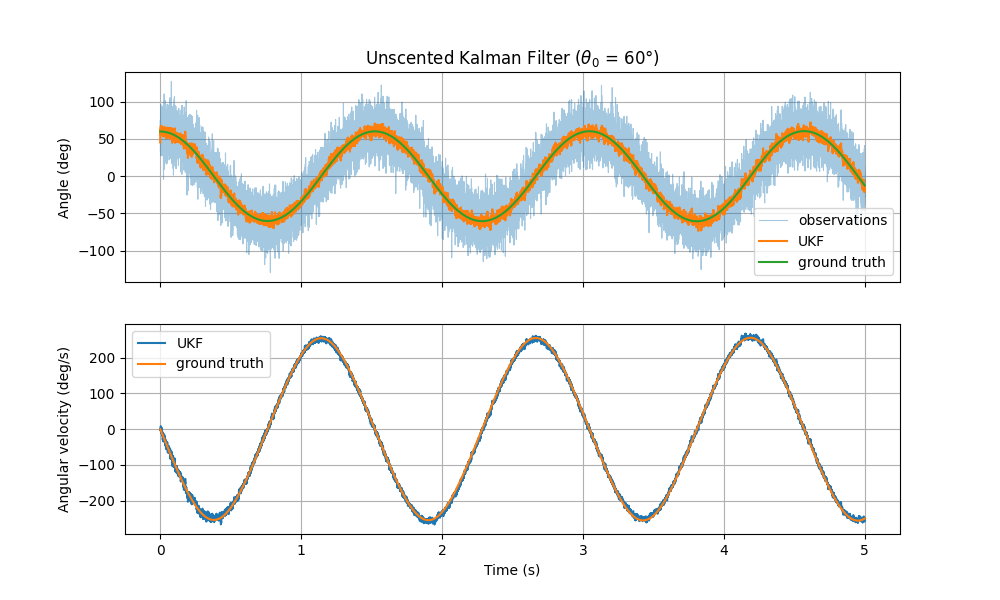

In [14]:
# Plot UKF result

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, np.rad2deg(z), label='observations', alpha=0.4, lw=0.8)
axes[0].plot(t, np.rad2deg(x_ukf[:, 0]), label='UKF', lw=1.5)
axes[0].plot(t, np.rad2deg(theta), label='ground truth', lw=1.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title(f'Unscented Kalman Filter ($\\theta_0$ = {np.rad2deg(theta_0):.0f}°)')

axes[1].plot(t, np.rad2deg(x_ukf[:, 1]), label='UKF', lw=1.5)
axes[1].plot(t, np.rad2deg(theta_dot), label='ground truth', lw=1.5)
axes[1].set_ylabel('Angular velocity (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [15]:
# Compute RMSE Unscented Kalman

# Angle theta
rmse_ukf_theta = compute_rmse(theta, x_ukf[:, 0])

# Angular velocity theta_dot
rmse_ukf_theta_dot = compute_rmse(theta_dot, x_ukf[:, 1])

print(f"Init angle: {np.round(np.rad2deg(theta_0))}")
print(f"    UKF angle RMSE: {np.rad2deg(rmse_ukf_theta):.4f} deg")
print(f"    UKF velocity RMSE: {np.rad2deg(rmse_ukf_theta_dot):.4f} deg/s")

Init angle: 60.0
    UKF angle RMSE: 4.0682 deg
    UKF velocity RMSE: 5.0923 deg/s


### UKF Results

| $\theta_0$ (deg) | Angle RMSE (deg) | Velocity RMSE (deg/s) |
|---|---|---|
| 15 | 4.10 | 6.73 |
| 30 | 4.08 | 5.86 |
| 45 | 4.16 | 5.23 |
| 60 | 4.07 | 5.09 |


- Velocity RMSE stable across all initial theta
    - consistent with EKF 
    - sigma point propagation through nonlinear f() handles 
      large angles correctly without linearization



## Overall Results

| $\theta_0$ (deg) | KF | EKF | UKF |
|---|---|---|---|
| 15 | 5.71 | 6.61 | 6.73 |
| 30 | 6.38 | 6.24 | 5.86 |
| 45 | 13.76 | 4.93 | 5.23 |
| 60 | 27.43 | 5.17 | 5.09 |

- UKF and EKF performance comparable on this problem
    - expected where first order Taylor series approx (EKF) performs adequately
- Both nonlinear methods dramatically outperform standard Kalman at large angles
- Where UKF advantage would be more pronounced:
    - stronger nonlinearity 
    - higher noise
    - Jacobian computation difficult